Using device: cpu
Scanning dataset...
  extra: 60 images
  short: 60 images
  long: 60 images
  back: 60 images

Split → train: 168, val: 24, test: 48
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 397MB/s]



Model: EfficientNetV2-S  |  Classes: ['extra', 'short', 'long', 'back']


 Epoch  Train Loss  Train Acc   Val Loss   Val Acc         LR  Time
───────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1      1.2198     0.5298     1.2483    0.5417   9.05e-05  43.9s ★
     2      0.6861     0.9464     0.5698    0.9583   6.58e-05  47.5s ★
     3      0.4333     0.9464     0.2528    1.0000   3.52e-05  46.5s ★
     4      0.2836     0.9643     0.1829    1.0000   1.05e-05  47.2s
     5      0.1844     0.9821     0.1783    1.0000   1.00e-06  46.0s

History saved → /kaggle/working/history.json
Best Val Acc: 1.0000


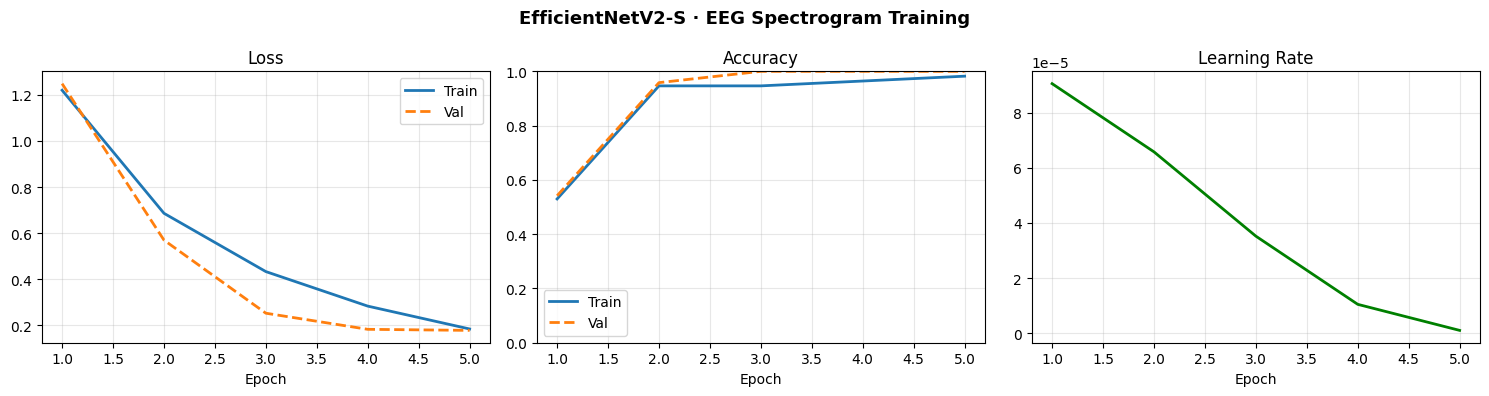

Training curves saved → /kaggle/working/training_curves.png

Loading best checkpoint for test evaluation...

──────────────────────────────────────────────────
Test Loss : 0.3531
Test Acc  : 0.9375  (93.8%)
──────────────────────────────────────────────────

Classification Report:

              precision    recall  f1-score   support

       extra     1.0000    1.0000    1.0000        12
       short     0.8462    0.9167    0.8800        12
        long     0.9231    1.0000    0.9600        12
        back     1.0000    0.8333    0.9091        12

    accuracy                         0.9375        48
   macro avg     0.9423    0.9375    0.9373        48
weighted avg     0.9423    0.9375    0.9373        48



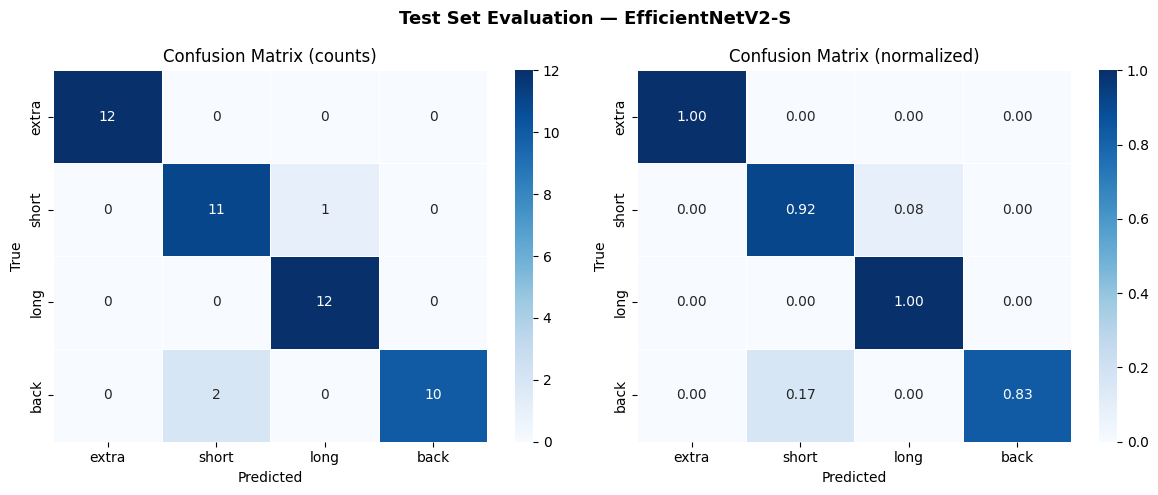

Evaluation plot saved → /kaggle/working/test_evaluation.png


In [ ]:
import os
import glob
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_ROOT    = "./BCI/spectrogram_data"
CLASSES      = ["extra", "short", "long", "back"]
IMG_SIZE     = 224
BATCH_SIZE   = 16
NUM_EPOCHS   = 5
LR           = 1e-4
WEIGHT_DECAY = 1e-4
SEED         = 42
SAVE_PATH    = "./BCI/train/eeg_classify.pth"
HISTORY_PATH = "./BCI/train/history.json"
PLOT_PATH    = "./BCI/train/training_curves.png"
EVAL_PATH    = "./BCI/train/test_evaluation.png"

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


def build_samples(data_root, classes):
    samples = []
    for label_idx, cls in enumerate(classes):
        folder = os.path.join(data_root, cls)
        paths  = sorted(glob.glob(os.path.join(folder, "*.png")))
        print(f"  {cls}: {len(paths)} images")
        for p in paths:
            samples.append((p, label_idx))
    return samples


def split_samples(samples, seed=42):
    """Stratified 70 / 10 / 20 split."""
    paths  = [s[0] for s in samples]
    labels = [s[1] for s in samples]

    p_tv, p_test, l_tv, l_test = train_test_split(
        paths, labels, test_size=0.20, stratify=labels, random_state=seed)

    p_train, p_val, l_train, l_val = train_test_split(
        p_tv, l_tv, test_size=0.125, stratify=l_tv, random_state=seed)

    train = list(zip(p_train, l_train))
    val   = list(zip(p_val,   l_val))
    test  = list(zip(p_test,  l_test))
    print(f"\nSplit → train: {len(train)}, val: {len(val)}, test: {len(test)}")
    return train, val, test


# ─────────────────────────────────────────────
# TRANSFORMS  (no augmentation)
# ─────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])


# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
def build_model(num_classes):
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model


# ─────────────────────────────────────────────
# EPOCH RUNNER
# ─────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer, is_train):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


# ─────────────────────────────────────────────
# PLOT TRAINING HISTORY
# ─────────────────────────────────────────────
def plot_history(history, save_path=PLOT_PATH):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("EfficientNetV2-S · EEG Spectrogram Training", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(epochs, history["val_loss"],   label="Val",   linewidth=2, linestyle="--")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train", linewidth=2)
    axes[1].plot(epochs, history["val_acc"],   label="Val",   linewidth=2, linestyle="--")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Learning Rate
    axes[2].plot(epochs, history["lr"], color="green", linewidth=2)
    axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch")
    axes[2].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Training curves saved → {save_path}")


# ─────────────────────────────────────────────
# TEST EVALUATION
# ─────────────────────────────────────────────
def evaluate_test(model, test_loader, criterion, classes, save_path=EVAL_PATH):
    """
    Run inference on test set, print classification report,
    and save confusion matrix figure.
    """
    model.eval()
    all_preds, all_labels = [], []
    total_loss, total = 0.0, 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            total_loss += loss.item() * imgs.size(0)
            total      += imgs.size(0)
            preds       = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / total
    test_acc  = np.mean(np.array(all_preds) == np.array(all_labels))

    print(f"\n{'─'*50}")
    print(f"Test Loss : {test_loss:.4f}")
    print(f"Test Acc  : {test_acc:.4f}  ({test_acc*100:.1f}%)")
    print(f"{'─'*50}\n")

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=classes, digits=4)
    print("Classification Report:\n")
    print(report)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalized

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Test Set Evaluation — EfficientNetV2-S", fontsize=13, fontweight="bold")

    for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ["Confusion Matrix (counts)", "Confusion Matrix (normalized)"],
        ["d", ".2f"],
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax,
        )
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Evaluation plot saved → {save_path}")

    return test_loss, test_acc


# ─────────────────────────────────────────────
# TRAIN
# ─────────────────────────────────────────────
def train(model, train_loader, val_loader, criterion, optimizer, scheduler):
    history = defaultdict(list)
    best_val_acc = 0.0

    print(f"\n{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} "
          f"{'Val Loss':>10} {'Val Acc':>9} {'LR':>10}  Time")
    print("─" * 75)

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, is_train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, optimizer, is_train=False)
        scheduler.step()

        lr_now  = scheduler.get_last_lr()[0]
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["lr"].append(lr_now)

        marker = " ★" if vl_acc > best_val_acc else ""
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), SAVE_PATH)

        print(f"{epoch:>6} {tr_loss:>11.4f} {tr_acc:>10.4f} "
              f"{vl_loss:>10.4f} {vl_acc:>9.4f} {lr_now:>10.2e}  "
              f"{elapsed:4.1f}s{marker}")

    with open(HISTORY_PATH, "w") as f:
        json.dump(dict(history), f, indent=2)
    print(f"\nHistory saved → {HISTORY_PATH}")
    print(f"Best Val Acc: {best_val_acc:.4f}")

    return history


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
def main():
    # ── Data ──────────────────────────────────
    print("Scanning dataset...")
    all_samples = build_samples(DATA_ROOT, CLASSES)
    train_s, val_s, test_s = split_samples(all_samples, seed=SEED)

    train_ds = EEGDataset(train_s, transform=base_transform)
    val_ds   = EEGDataset(val_s,   transform=base_transform)
    test_ds  = EEGDataset(test_s,  transform=base_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    # ── Model / Optimizer ─────────────────────
    model     = build_model(num_classes=len(CLASSES)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    print(f"\nModel: EfficientNetV2-S  |  Classes: {CLASSES}\n")

    # ── Train ─────────────────────────────────
    history = train(model, train_loader, val_loader, criterion, optimizer, scheduler)

    # ── Plot history ──────────────────────────
    plot_history(history)

    # ── Test ──────────────────────────────────
    print("\nLoading best checkpoint for test evaluation...")
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    evaluate_test(model, test_loader, criterion, CLASSES)


if __name__ == "__main__":
    main()